In [36]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn import set_config
set_config(display="diagram")
# import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.compose import ColumnTransformer

# Import necessary libraries
from sklearn.impute import SimpleImputer    
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# import k-nearest neighbors
from sklearn.neighbors import KNeighborsClassifier

# import decision tree classifier
from sklearn.tree import DecisionTreeClassifier

# import random forest classifier
from sklearn.ensemble import RandomForestClassifier
# import gradient boosting classifier
from sklearn.ensemble import GradientBoostingClassifier
# import support vector classifier
from sklearn.svm import SVC


import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

### **Comparing the performance of different ML classifiers**  
This notebook will compare the performance of different ML classifiers (e.g. k-nearest neighbors, logistic regression, decision trees, and support vector machines). We will use the Bank marketing dataset provided from the UC Irvine Machine Learning Repository. 

# **Business understanding**

The business goal is to find a model that can explain success of a contact, i.e. if the client subscribes the deposit. Using the Bank marketing dataset, I will do some analysis to determine which factors drive the success of a marketing campaign. I will perform exploratory data analysis and build Machine Learning models to find the key drivers of a marketing campaign. I will also build multiple models with different ML classifiers (e.g. k-nearest neighbors, logistic regression, decision trees, and support vector machines) to find the best one for this task.

# **Data Understanding**

In this section I will explore the vehicles dataset to understand the fpllowing aspects:

* **Data types:** how many variables are there? What data types? Are there only numeric variables or also categorigal ones?  
* **data quality:** How many missing values are there? How many variables have a single value for all rows?
* **Correlations:** Which variables are correlated with each other or with price?
* **Data distributions:** What is the distribution of the variables? Which of them are skewed?
* **Outliers:** Are there aany outliers in the dataset? If so, how do we handle them?





In [3]:
# df = pd.read_csv('data/bank-additional-full.csv')

df = pd.read_csv('data/bank-additional-full.csv', sep=';')

In [4]:
df.shape

(41188, 21)

In [5]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [7]:
# show missing variables
df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [8]:
df = df.dropna()
df.shape



(41188, 21)

In [11]:
# Show how many values in each column has the value with the "unknown" label
unknown_counts = df.apply(lambda x: (x == 'unknown').sum())
unknown_counts = unknown_counts[unknown_counts > 0] 
print("Columns with 'unknown' values:")
print(unknown_counts)

Columns with 'unknown' values:
job           330
marital        80
education    1731
default      8597
housing       990
loan          990
dtype: int64


In [13]:
# 1. Drop the rows with 'unknown' values
df = df.replace('unknown', np.nan)
df = df.dropna()
df.shape


(30488, 21)

In [14]:
df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [15]:
# Show how many values in each column has the value with the "unknown" label
unknown_counts = df.apply(lambda x: (x == 'unknown').sum())
unknown_counts = unknown_counts[unknown_counts > 0] 
print("Columns with 'unknown' values:")
print(unknown_counts)

Columns with 'unknown' values:
Series([], dtype: int64)


In [16]:
# show variables that have the same value for all rows
df.nunique()


age                 76
job                 11
marital              3
education            7
default              2
housing              2
loan                 2
contact              2
month               10
day_of_week          5
duration          1441
campaign            41
pdays               26
previous             8
poutcome             3
emp.var.rate        10
cons.price.idx      26
cons.conf.idx       26
euribor3m          314
nr.employed         11
y                    2
dtype: int64

In [17]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [91]:
# Drop the duration column
df = df.drop(columns=['duration'])
df.shape

(30488, 20)

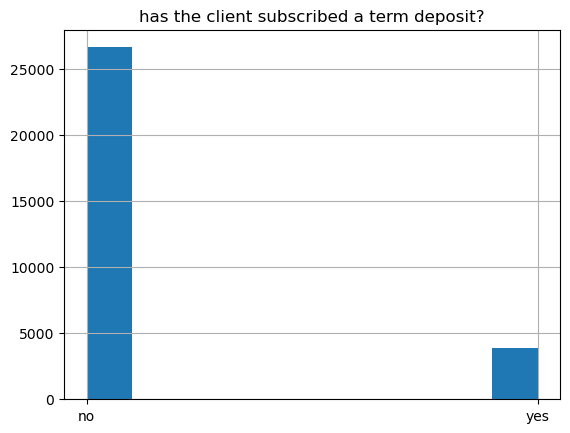

In [18]:
df['y'].hist()
plt.title('has the client subscribed a term deposit?')
plt.show()

In [90]:
# show the rate of clients who subscribed a term deposit
subscribed_rate = df['y'].value_counts(normalize=True)
print("Rate of clients who subscribed a term deposit:")
print(subscribed_rate)

Rate of clients who subscribed a term deposit:
y
no     0.873426
yes    0.126574
Name: proportion, dtype: float64


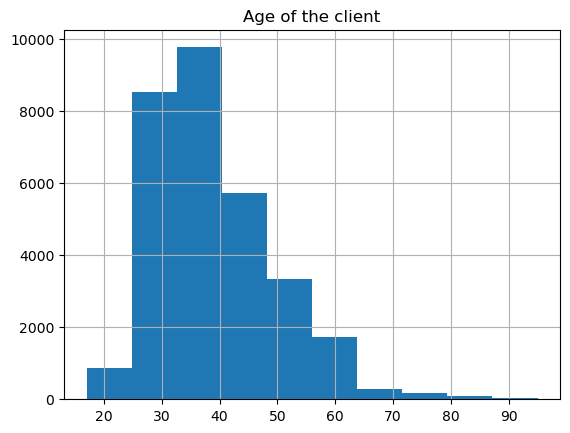

In [19]:
# plot the histogram of the age of the client
df['age'].hist()
plt.title('Age of the client')
plt.show()

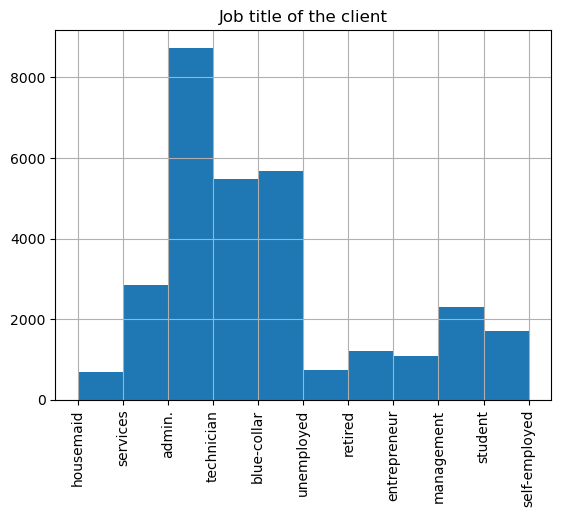

In [20]:
df['job'].hist()
plt.title('Job title of the client')
plt.xticks(rotation=90)
plt.show()

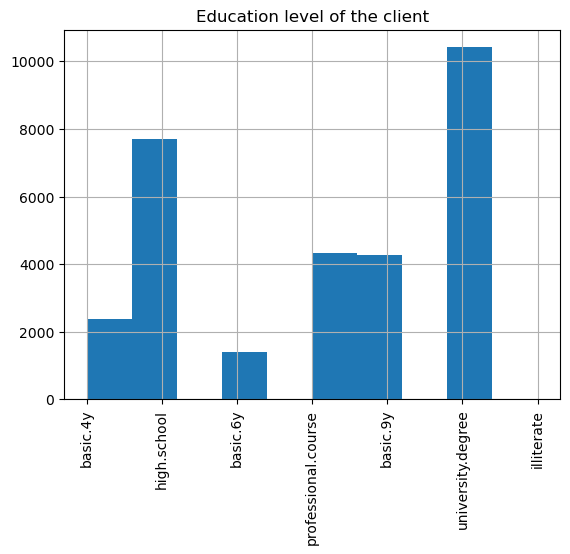

In [21]:
df['education'].hist()
plt.title('Education level of the client')
plt.xticks(rotation=90)
plt.show()

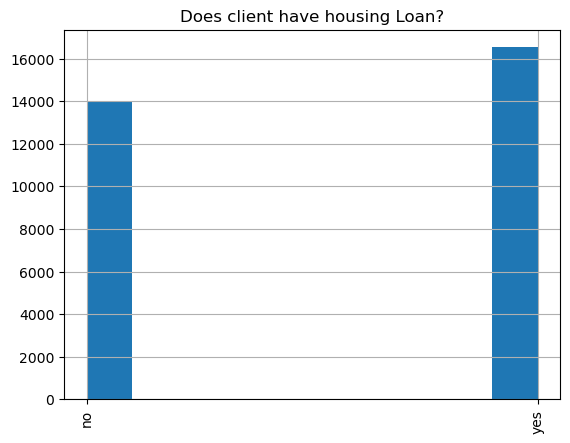

In [23]:
df['housing'].hist()
plt.title('Does client have housing Loan?')
plt.xticks(rotation=90)
plt.show()

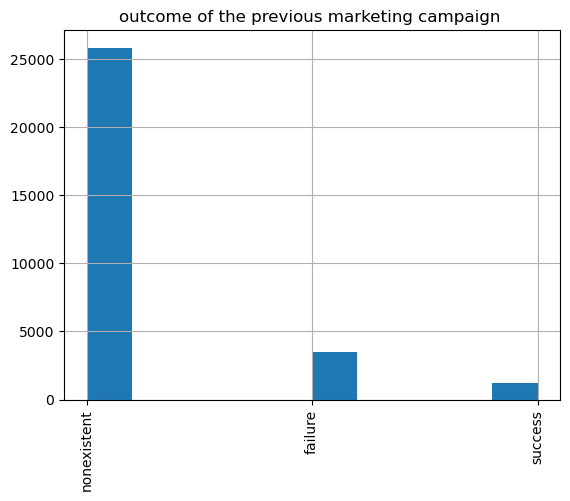

In [24]:
df['poutcome'].hist()
plt.title('outcome of the previous marketing campaign ')
plt.xticks(rotation=90)
plt.show()




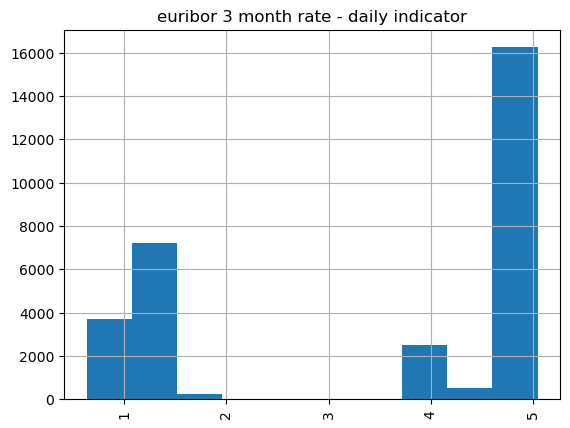

In [25]:
df['euribor3m'].hist()
plt.title('euribor 3 month rate - daily indicator')
plt.xticks(rotation=90)
plt.show()


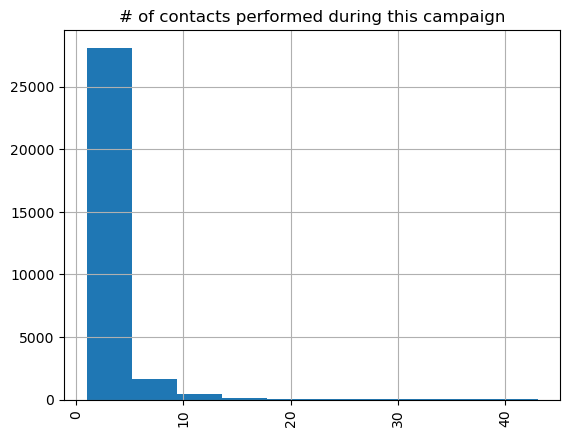

In [26]:
df['campaign'].hist()
plt.title('# of contacts performed during this campaign')
plt.xticks(rotation=90)
plt.show()
#

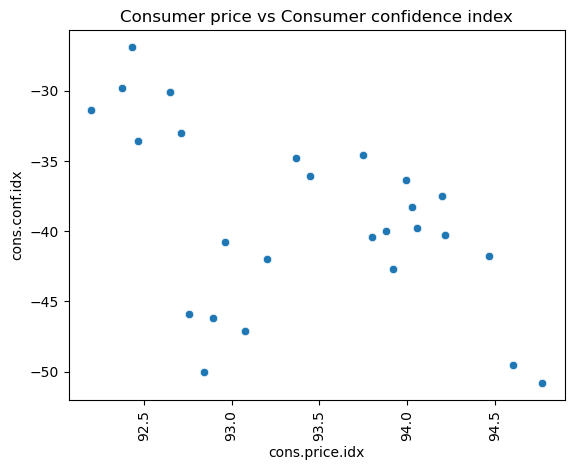

In [28]:
# Consumer price index vs consumer confidence index
sns.scatterplot(x='cons.price.idx', y='cons.conf.idx', data=df)
plt.title('Consumer price vs Consumer confidence index')
plt.xticks(rotation=90)
plt.show()

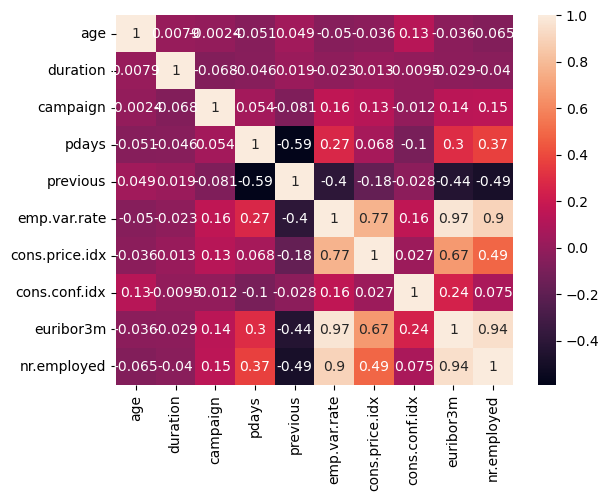

In [29]:
# Check correlations
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True)
plt.show()

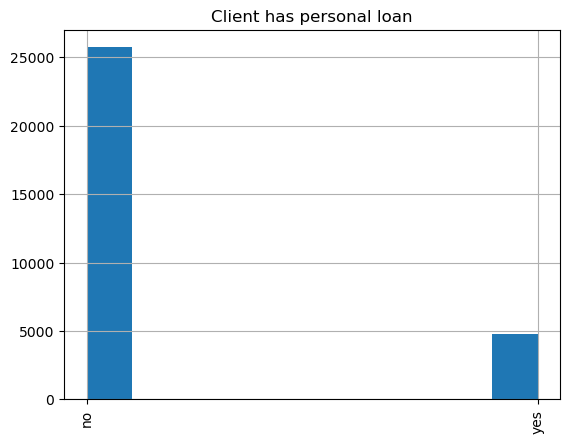

In [30]:
df['loan'].hist()
plt.title('Client has personal loan')
plt.xticks(rotation=90)
plt.show()


# **Data Preparation**

In [31]:
# Split the data into X_train, X_test, y_train and y_test
X = df.drop(columns=['y'])
y = df['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
X_train.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
13510,36,admin.,single,high.school,no,yes,no,telephone,jul,thu,140,1,999,0,nonexistent,1.4,93.918,-42.7,4.963,5228.1
19974,38,technician,married,professional.course,no,yes,no,cellular,aug,fri,848,1,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1
32016,51,self-employed,married,high.school,no,yes,no,cellular,may,thu,43,2,999,1,failure,-1.8,92.893,-46.2,1.327,5099.1
16853,55,admin.,married,basic.4y,no,no,no,cellular,jul,thu,134,1,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1
28160,43,services,married,professional.course,no,no,no,cellular,apr,mon,230,1,999,0,nonexistent,-1.8,93.075,-47.1,1.466,5099.1


In [33]:
X_test.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
8688,27,services,single,high.school,no,yes,no,telephone,jun,wed,179,1,999,0,nonexistent,1.4,94.465,-41.8,4.864,5228.1
18409,27,blue-collar,single,basic.4y,no,no,no,cellular,jul,thu,508,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1
18374,37,entrepreneur,divorced,high.school,no,yes,no,cellular,jul,thu,812,2,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1
39804,29,technician,single,professional.course,no,yes,no,cellular,jun,wed,226,2,6,1,success,-1.7,94.055,-39.8,0.704,4991.6
10746,28,services,single,high.school,no,no,no,telephone,jun,tue,406,3,999,0,nonexistent,1.4,94.465,-41.8,4.961,5228.1


In [41]:
# Create a ColumnTransformer to apply different transformations to different column types
from sklearn.compose import ColumnTransformer

# Identify categorical and numerical columns
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns
numerical_features = X_train.select_dtypes(include=np.number).columns

# Create the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('scaler', StandardScaler(), numerical_features)
    ],
    remainder='passthrough' # Keep other columns (if any) as they are
)

In [42]:
# Create a pipepline that does the following: 1) Uses onehotencoder to encode categorical variables in df, scales numerical variables, then performs Logistic regression .
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, solver='saga', tol=0.1))
])

In [44]:
# Use GridSearch to build a model with the above pipeline, pipe
param_grid = {
    'model__C': [0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
}

grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(X_train, y_train)

# You can then access the best parameters and score like this:
print("Best parameters:", grid.best_params_)
print("Best cross-validation score:", grid.best_score_)

Best parameters: {'model__C': 1, 'model__penalty': 'l1'}
Best cross-validation score: 0.9011070110701107


In [45]:
# show best model and its coefficients
print(grid.best_estimator_)
print(grid.best_estimator_.named_steps['model'].coef_)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')),
                                                 ('scaler', StandardScaler(),
                                                  Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object'))])),
                ('model',
                 LogisticRegression(C=1, max_iter=1000, penalty='l1',
                                    solver='saga', tol=0.1))])
[[-0.01033841 -0.3398676  -0.1806995  -0.03554815 -0.06756975  0.25145516
  -0.03395588 -0.18086374 

In [47]:
best = grid.best_estimator_
model = best.named_steps['model']
pre = best.named_steps['preprocessor']

coefs = model.coef_                 # shape (1, n_features)
feature_names = pre.get_feature_names_out()

importances = coefs.ravel()         # shape (n_features,)
important_features = pd.Series(importances, index=feature_names)

# Often you want magnitude:
important_features = important_features.abs().sort_values(ascending=False)
print(important_features)
# Plot the important features
plt.figure(figsize=(10, 6))

scaler__duration                         1.179458
onehot__month_mar                        1.177326
onehot__month_may                        0.869984
scaler__emp.var.rate                     0.807076
onehot__default_no                       0.587448
onehot__poutcome_failure                 0.562896
onehot__month_nov                        0.465372
onehot__contact_telephone                0.464968
scaler__nr.employed                      0.402877
onehot__job_blue-collar                  0.339868
scaler__cons.price.idx                   0.331666
onehot__housing_yes                      0.305334
onehot__loan_no                          0.297768
scaler__pdays                            0.277632
onehot__day_of_week_mon                  0.272630
onehot__loan_yes                         0.266882
onehot__housing_no                       0.259317
onehot__job_retired                      0.251455
onehot__month_sep                        0.242345
onehot__marital_divorced                 0.229322


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [50]:
important_features.head(20)

scaler__duration             1.179458
onehot__month_mar            1.177326
onehot__month_may            0.869984
scaler__emp.var.rate         0.807076
onehot__default_no           0.587448
onehot__poutcome_failure     0.562896
onehot__month_nov            0.465372
onehot__contact_telephone    0.464968
scaler__nr.employed          0.402877
onehot__job_blue-collar      0.339868
scaler__cons.price.idx       0.331666
onehot__housing_yes          0.305334
onehot__loan_no              0.297768
scaler__pdays                0.277632
onehot__day_of_week_mon      0.272630
onehot__loan_yes             0.266882
onehot__housing_no           0.259317
onehot__job_retired          0.251455
onehot__month_sep            0.242345
onehot__marital_divorced     0.229322
dtype: float64

In [51]:
important_features.tail(20)

onehot__poutcome_nonexistent           0.081080
onehot__job_management                 0.067570
onehot__day_of_week_thu                0.065064
scaler__cons.conf.idx                  0.061895
onehot__month_jun                      0.057547
onehot__education_university.degree    0.056606
onehot__day_of_week_tue                0.055112
onehot__poutcome_success               0.053964
onehot__job_technician                 0.050255
scaler__previous                       0.037236
onehot__job_housemaid                  0.035548
onehot__job_self-employed              0.033956
onehot__month_oct                      0.022597
onehot__month_jul                      0.018133
onehot__day_of_week_wed                0.011945
onehot__job_admin.                     0.010338
scaler__age                            0.006142
onehot__job_unemployed                 0.002151
onehot__default_yes                    0.000000
onehot__education_illiterate           0.000000
dtype: float64

In [52]:
from sklearn.inspection import permutation_importance

# Calculate the permutation importance using the fitted pipeline
results = permutation_importance(grid.best_estimator_, X_test, y_test)

# Use the original feature names from X_test
importances = pd.DataFrame(
	data=results.importances_mean,
	index=X_test.columns,
	columns=['Importance']
).sort_values(by='Importance', ascending=False)
print(importances)

                  Importance
duration        3.834044e-02
emp.var.rate    8.822565e-03
pdays           5.739587e-03
nr.employed     5.575599e-03
cons.price.idx  3.443752e-03
month           3.345359e-03
job             1.672680e-03
contact         9.183339e-04
campaign        8.855362e-04
day_of_week     7.543457e-04
euribor3m       7.543457e-04
education       2.623811e-04
cons.conf.idx   2.623811e-04
age             1.639882e-04
loan            1.311906e-04
poutcome        6.559528e-05
previous        2.220446e-17
default         0.000000e+00
marital        -9.839292e-05
housing        -2.951787e-04


In [54]:
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, accuracy_score

best = grid.best_estimator_
model = best.named_steps['model']

# choose your positive class explicitly
positive = 'yes'   # <- change if your "positive" is different

# Predictions
y_pred = grid.predict(X_test)

# Find the column index in predict_proba corresponding to the positive class
pos_idx = np.where(model.classes_ == positive)[0][0]
y_score = grid.predict_proba(X_test)[:, pos_idx]

# Metrics (explicitly set pos_label for binary string labels)
lr_f1 = f1_score(y_test, y_pred, pos_label=positive)
lr_precision = precision_score(y_test, y_pred, pos_label=positive)
lr_recall = recall_score(y_test, y_pred, pos_label=positive)
lr_auc = roc_auc_score(y_test, y_score)                    # y_score is prob of "positive"
lr_acc = accuracy_score(y_test, y_pred)

print("F1:", lr_f1)
print("Precision:", lr_precision)
print("Recall:", lr_recall)
print("AUC:", lr_auc)
print("Accuracy:", lr_acc)
# Plot the ROC curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_score, pos_label=positive)
plt.figure(figsize=(8, 6))


F1: 0.5180630284396618
Precision: 0.6646942800788954
Recall: 0.4244332493702771
AUC: 0.9267776137775398
Accuracy: 0.897179403082978


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

In [59]:
# Create the ColumnTransformer
preprocessor2 = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ('scaler', StandardScaler(), numerical_features)
    ],
    remainder='passthrough' # Keep other columns (if any) as they are
)

In [60]:
# Now build a pipeline that uses k-Nearest Neighbors classifier
knn_pipe = Pipeline([
    ('preprocessor2', preprocessor),
    ('model', KNeighborsClassifier())
])


In [62]:
# Use GridSearch to build a model with the above pipeline, pipe
param_grid = {
    'model__n_neighbors': [3, 5, 7, 9],  # Number of neighbors
    'model__weights': ['uniform', 'distance'],  # Weight function
    'model__metric': ['minkowski'],  # Distance metric
    'model__p': [1, 2],
}

grid = GridSearchCV(knn_pipe, param_grid, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

# You can then access the best parameters and score like this:
print("Best parameters:", grid.best_params_)
print("Best cross-validation score:", grid.best_score_)

Best parameters: {'model__metric': 'minkowski', 'model__n_neighbors': 9, 'model__p': 2, 'model__weights': 'uniform'}
Best cross-validation score: 0.8947519475194751


c:\Users\Valentine Fontama\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:1102: UserWarning: One or more of the test scores are non-finite: [       nan 0.88130381 0.88593686 0.88495285        nan 0.88523985
 0.8897499  0.88880689        nan 0.88798688 0.89204592 0.89118491
        nan 0.8896679  0.89475195 0.89397294]
  warnings.warn(


F1: 0.4789594491201224
Precision: 0.6101364522417154
Recall: 0.39420654911838793
AUC: 0.8995502895015784
Accuracy: 0.8883240406690718


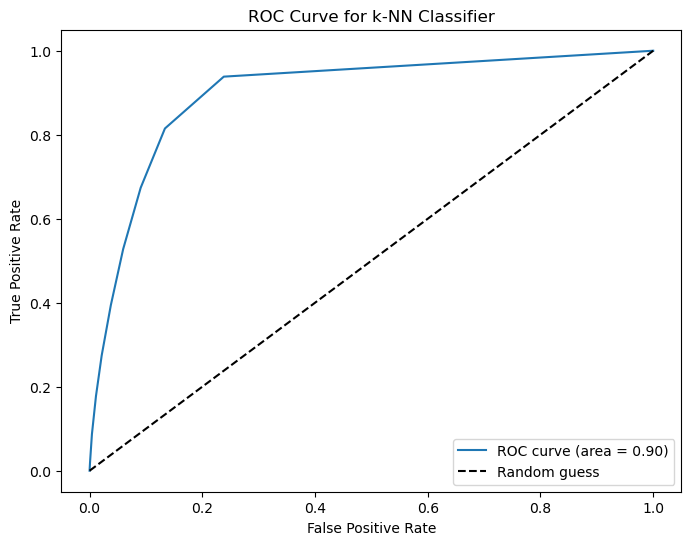

In [63]:
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, accuracy_score

best = grid.best_estimator_
model = best.named_steps['model']

# choose your positive class explicitly
positive = 'yes'   # <- change if your "positive" is different

# Predictions
y_pred = grid.predict(X_test)

# Find the column index in predict_proba corresponding to the positive class
pos_idx = np.where(model.classes_ == positive)[0][0]
y_score = grid.predict_proba(X_test)[:, pos_idx]

# Metrics (explicitly set pos_label for binary string labels)
knn_f1 = f1_score(y_test, y_pred, pos_label=positive)
knn_precision = precision_score(y_test, y_pred, pos_label=positive)
knn_recall = recall_score(y_test, y_pred, pos_label=positive)
knn_auc = roc_auc_score(y_test, y_score)                    # y_score is prob of "positive"
knn_acc = accuracy_score(y_test, y_pred)

print("F1:", knn_f1)
print("Precision:", knn_precision)
print("Recall:", knn_recall)
print("AUC:", knn_auc)
print("Accuracy:", knn_acc)
# Plot the ROC curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_score, pos_label=positive)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC curve (area = {:.2f})'.format(knn_auc))
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')   
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for k-NN Classifier')
plt.legend()
plt.show()

## Decision Tree model

In [65]:
# Now build a pipeline that uses Decision Tree classifier
dt_pipe = Pipeline([
    ('preprocessor2', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

In [67]:
# Define the parameter grid
param_grid = {
    'model__criterion': ['gini', 'entropy'],  # Splitting criteria
    'model__max_depth': [3, 5, 10, None],     # Maximum depth of the tree
    'model__min_samples_split': [2, 5, 10],   # Minimum samples required to split a node
    'model__min_samples_leaf': [1, 2, 4]      # Minimum samples required at a leaf node
}

grid = GridSearchCV(dt_pipe, param_grid, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

# You can then access the best parameters and score like this:
print("Best parameters:", grid.best_params_)
print("Best cross-validation score:", grid.best_score_)

Best parameters: {'model__criterion': 'entropy', 'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Best cross-validation score: 0.9059450594505944


F1: 0.5974547890154053
Precision: 0.6380543633762518
Recall: 0.5617128463476071
AUC: 0.923095088161209
Accuracy: 0.9014430960970811


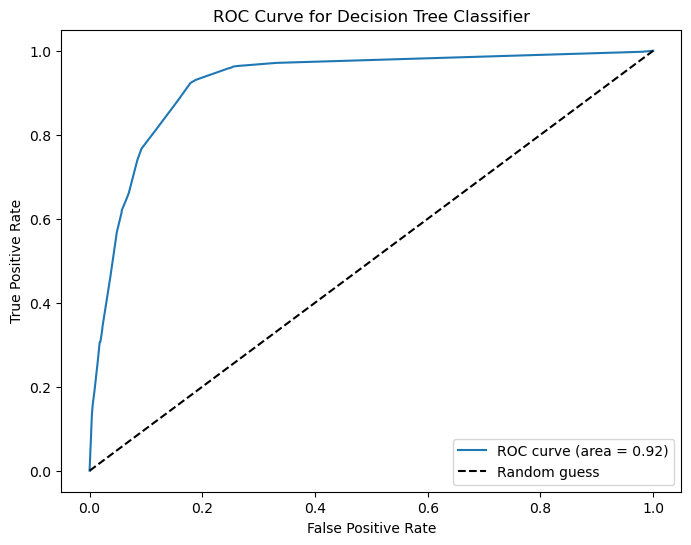

In [68]:
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, accuracy_score

best = grid.best_estimator_
model = best.named_steps['model']

# choose your positive class explicitly
positive = 'yes'   # <- change if your "positive" is different

# Predictions
y_pred = grid.predict(X_test)

# Find the column index in predict_proba corresponding to the positive class
pos_idx = np.where(model.classes_ == positive)[0][0]
y_score = grid.predict_proba(X_test)[:, pos_idx]

# Metrics (explicitly set pos_label for binary string labels)
dt_f1 = f1_score(y_test, y_pred, pos_label=positive)
dt_precision = precision_score(y_test, y_pred, pos_label=positive)
dt_recall = recall_score(y_test, y_pred, pos_label=positive)
dt_auc = roc_auc_score(y_test, y_score)                    # y_score is prob of "positive"
dt_acc = accuracy_score(y_test, y_pred)

print("F1:", dt_f1)
print("Precision:", dt_precision)
print("Recall:", dt_recall)
print("AUC:", dt_auc)
print("Accuracy:", dt_acc)
# Plot the ROC curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_score, pos_label=positive)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC curve (area = {:.2f})'.format(dt_auc))
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')   
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Decision Tree Classifier')
plt.legend()
plt.show()

In [69]:
from sklearn.inspection import permutation_importance

# Calculate the permutation importance using the fitted pipeline
results = permutation_importance(grid.best_estimator_, X_test, y_test)

# Use the original feature names from X_test
importances = pd.DataFrame(
	data=results.importances_mean,
	index=X_test.columns,
	columns=['Importance']
).sort_values(by='Importance', ascending=False)
print(importances)

                Importance
duration          0.066907
nr.employed       0.042047
euribor3m         0.015579
month             0.012430
cons.conf.idx     0.007642
cons.price.idx    0.006756
pdays             0.003542
marital           0.000000
emp.var.rate      0.000000
poutcome          0.000000
previous          0.000000
age               0.000000
education         0.000000
job               0.000000
day_of_week       0.000000
contact           0.000000
loan              0.000000
housing           0.000000
default           0.000000
campaign         -0.000164


## RandomForest model

In [92]:
# Now build a pipeline that uses RandomForest classifier
rf_pipe = Pipeline([
    ('preprocessor2', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])


In [93]:
# Define the parameter grid
param_grid = {
    'model__n_estimators': [50, 100, 200],  # Number of trees in the forest
    'model__max_depth': [None, 10, 20, 30],  # Maximum depth of the tree
    'model__min_samples_split': [2, 5, 10],  # Minimum samples required to split a node
    'model__min_samples_leaf': [1, 2, 4],    # Minimum samples required at a leaf node
    'model__bootstrap': [True, False]        # Whether bootstrap samples are used
}

grid = GridSearchCV(rf_pipe, param_grid, cv=5, scoring='accuracy', verbose=2, n_jobs=-1)
grid.fit(X_train, y_train)

# You can then access the best parameters and score like this:
print("Best parameters:", grid.best_params_)
print("Best cross-validation score:", grid.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best parameters: {'model__bootstrap': True, 'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 100}
Best cross-validation score: 0.906519065190652


F1: 0.5432656132430399
Precision: 0.6747663551401869
Recall: 0.45465994962216627
AUC: 0.9381088271386835
Accuracy: 0.9004591669399803


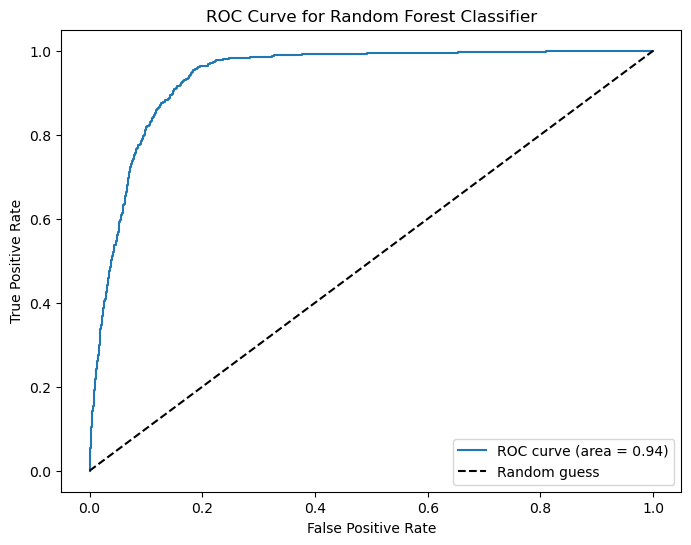

In [94]:
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, accuracy_score

best = grid.best_estimator_
model = best.named_steps['model']

# choose your positive class explicitly
positive = 'yes'   # <- change if your "positive" is different

# Predictions
y_pred = grid.predict(X_test)

# Find the column index in predict_proba corresponding to the positive class
pos_idx = np.where(model.classes_ == positive)[0][0]
y_score = grid.predict_proba(X_test)[:, pos_idx]

# Metrics (explicitly set pos_label for binary string labels)
rf_f1 = f1_score(y_test, y_pred, pos_label=positive)
rf_precision = precision_score(y_test, y_pred, pos_label=positive)
rf_recall = recall_score(y_test, y_pred, pos_label=positive)
rf_auc = roc_auc_score(y_test, y_score)                    # y_score is prob of "positive"
rf_acc = accuracy_score(y_test, y_pred)

print("F1:", rf_f1)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("AUC:", rf_auc)
print("Accuracy:", rf_acc)
# Plot the ROC curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_score, pos_label=positive)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC curve (area = {:.2f})'.format(rf_auc))
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')   
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Random Forest Classifier')
plt.legend()
plt.show()

In [95]:
from sklearn.inspection import permutation_importance

# Calculate the permutation importance using the fitted pipeline
results = permutation_importance(grid.best_estimator_, X_test, y_test)

# Use the original feature names from X_test
importances = pd.DataFrame(
	data=results.importances_mean,
	index=X_test.columns,
	columns=['Importance']
).sort_values(by='Importance', ascending=False)
print(importances)

                  Importance
duration        4.155461e-02
euribor3m       7.215480e-03
nr.employed     5.870777e-03
contact         4.657265e-03
emp.var.rate    4.329288e-03
month           2.164644e-03
education       1.869465e-03
cons.price.idx  1.475894e-03
day_of_week     1.344703e-03
pdays           1.279108e-03
poutcome        1.082322e-03
loan            7.543457e-04
cons.conf.idx   5.247622e-04
default         0.000000e+00
housing        -4.440892e-17
campaign       -1.311906e-04
previous       -6.887504e-04
job            -6.887504e-04
marital        -6.887504e-04
age            -1.115120e-03


## Support Vector Machine model

In [83]:
# Now build a pipeline that uses Support Vector Machine classifier
svm_pipe = Pipeline([
    ('preprocessor3', preprocessor),
    ('model', SVC(kernel='rbf'))
])

In [84]:
# Define the parameter grid
param_grid = {
    'model__C': [0.1, 1, 10, 100],       # Regularization parameter
    'model__gamma': [1, 0.1, 0.01, 0.001]  # Kernel coefficient 
}

grid = GridSearchCV(svm_pipe, param_grid, cv=5, scoring='accuracy', verbose=2, n_jobs=-1)
grid.fit(X_train, y_train)

# You can then access the best parameters and score like this:
print("Best parameters:", grid.best_params_)
print("Best cross-validation score:", grid.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters: {'model__C': 100, 'model__gamma': 0.01}
Best cross-validation score: 0.9021730217302173


F1: 0.5061162079510704
Precision: 0.6439688715953308
Recall: 0.4168765743073048
AUC: 0.9169625319610503
Accuracy: 0.8940636274188258


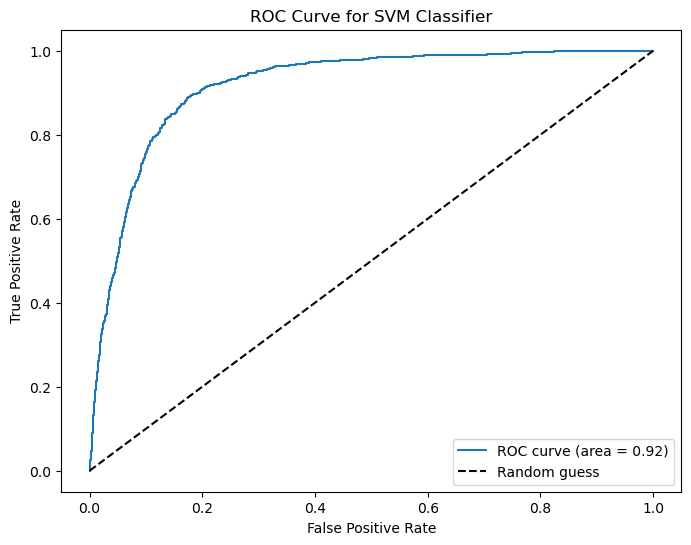

In [86]:
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, accuracy_score, roc_curve

best = grid.best_estimator_
model = best.named_steps['model']          # your SVC in the pipeline

positive = 'yes'                           # set your positive label

# Predictions (hard labels)
y_pred = grid.predict(X_test)

# Decision scores (no retrain needed)
# For binary SVC: decision_function > 0 corresponds to model.classes_[1]
# Flip the sign if your desired positive label isn't classes_[1]
classes = model.classes_
scores = best.decision_function(X_test)    # use best estimator’s method for clarity
if scores.ndim > 1:
    # (In case of unexpected shape; usually 1-D for binary SVC)
    scores = scores.ravel()

if positive != classes[1]:
    y_score = -scores
else:
    y_score = scores

# Metrics
svm_f1 = f1_score(y_test, y_pred, pos_label=positive)
svm_precision = precision_score(y_test, y_pred, pos_label=positive)
svm_recall = recall_score(y_test, y_pred, pos_label=positive)
svm_auc = roc_auc_score(y_test, y_score)   # uses decision scores just fine
svm_acc = accuracy_score(y_test, y_pred)

print("F1:", svm_f1)
print("Precision:", svm_precision)
print("Recall:", svm_recall)
print("AUC:", svm_auc)
print("Accuracy:", svm_acc)

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_score, pos_label=positive)

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC curve (area = {:.2f})'.format(svm_auc))
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for SVM Classifier')
plt.legend()
plt.show()


                 Model  F1 Score  Precision    Recall       AUC  Accuracy
3        Random Forest  0.543266   0.674766  0.454660  0.938109  0.900459
0  Logistic Regression  0.518063   0.664694  0.424433  0.926778  0.897179
2        Decision Tree  0.597455   0.638054  0.561713  0.923095  0.901443
4                  SVM  0.506116   0.643969  0.416877  0.916963  0.894064
1                 k-NN  0.478959   0.610136  0.394207  0.899550  0.888324


<Figure size 1000x600 with 0 Axes>

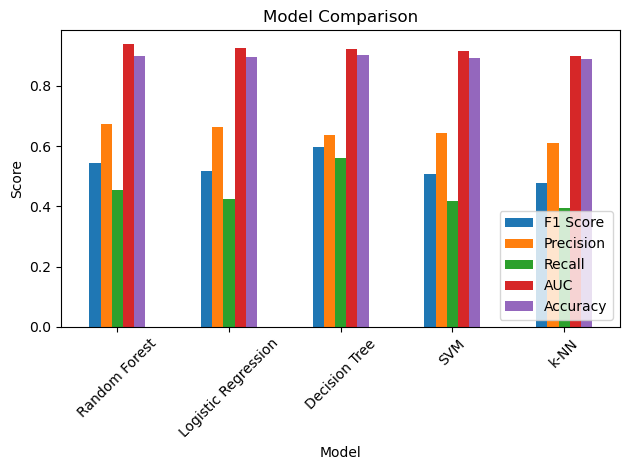

In [89]:
# Finnaly, create a table to compare the models. Show the results in a table for all the models built so far
results = {
    'Model': ['Logistic Regression', 'k-NN', 'Decision Tree', 'Random Forest', 'SVM'],
    'F1 Score': [lr_f1, knn_f1, dt_f1, rf_f1, svm_f1],
    'Precision': [lr_precision, knn_precision, dt_precision, rf_precision, svm_precision],
    'Recall': [lr_recall, knn_recall, dt_recall, rf_recall, svm_recall],
    'AUC': [lr_auc, knn_auc, dt_auc, rf_auc, svm_auc],
    'Accuracy': [lr_acc, knn_acc, dt_acc, rf_acc, svm_acc]
}
results_df = pd.DataFrame(results)
results_df.sort_values(by='AUC', ascending=False, inplace=True)
print(results_df)
# Save the results to a CSV file
results_df.to_csv('model_comparison_results.csv', index=False)

# Plot a bar chart to compare the models
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
results_df.set_index('Model').plot(kind='bar', rot=45)
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()



